In [1]:
%matplotlib widget

import os
import json
import numpy as np
import torch as th
import motornet as mn
import pickle
import matplotlib.pyplot as plt

from my_policy import Policy         # the RNN
from my_env    import ExperimentEnv  # the environment
from my_task   import ExperimentTask # the task
from my_utils  import run_episode    # run a batch of simulations
from my_utils  import plot_losses    # for plotting loss history
from my_utils  import plot_handpaths # for plotting hand paths
from my_utils  import plot_signals   # for plotting inputs and outputs per trial
from my_utils  import save_model     # for saving model config, weights, losses to disk
from my_utils  import load_model     # for loading model config and weights from disk

print('All packages imported.')
print('pytorch version: ' + th.__version__)
print('numpy version: ' + np.__version__)
print('motornet version: ' + mn.__version__)

All packages imported.
pytorch version: 2.8.0
numpy version: 2.3.3
motornet version: 0.2.0


In [2]:
# LOAD A MODEL AND TEST IT ON CENTER-OUT REACHES

save_name = "demo1"

n_tg     = 8    # number of targets for center-out task
sim_time = 3.00 # simulation time (seconds)
FF_k     = 0    # FF strength

print(f"loading model {save_name}")
env,task,policy,device = load_model(os.path.join(save_name,f"{save_name}_cfg.json"), os.path.join(save_name,f"{save_name}_weights.pkl"))

n_t = int(sim_time / env.dt)           # number of simulation steps
task.run_mode = 'test_center_out'      # center-out reaches

print(f"simulating {task.run_mode}")
episode_data = run_episode(env, task, policy, n_tg, n_t, device, k=FF_k) # run the batch forwards


loading model demo1
simulating test_center_out


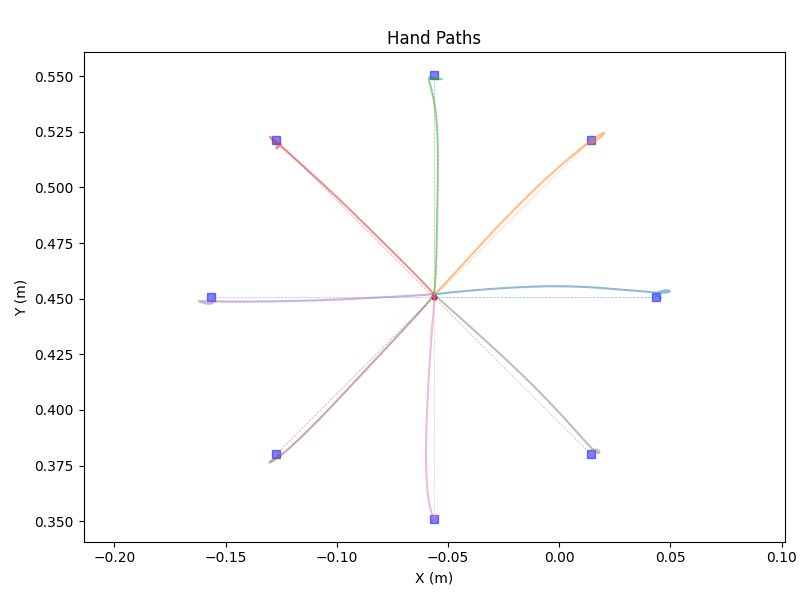

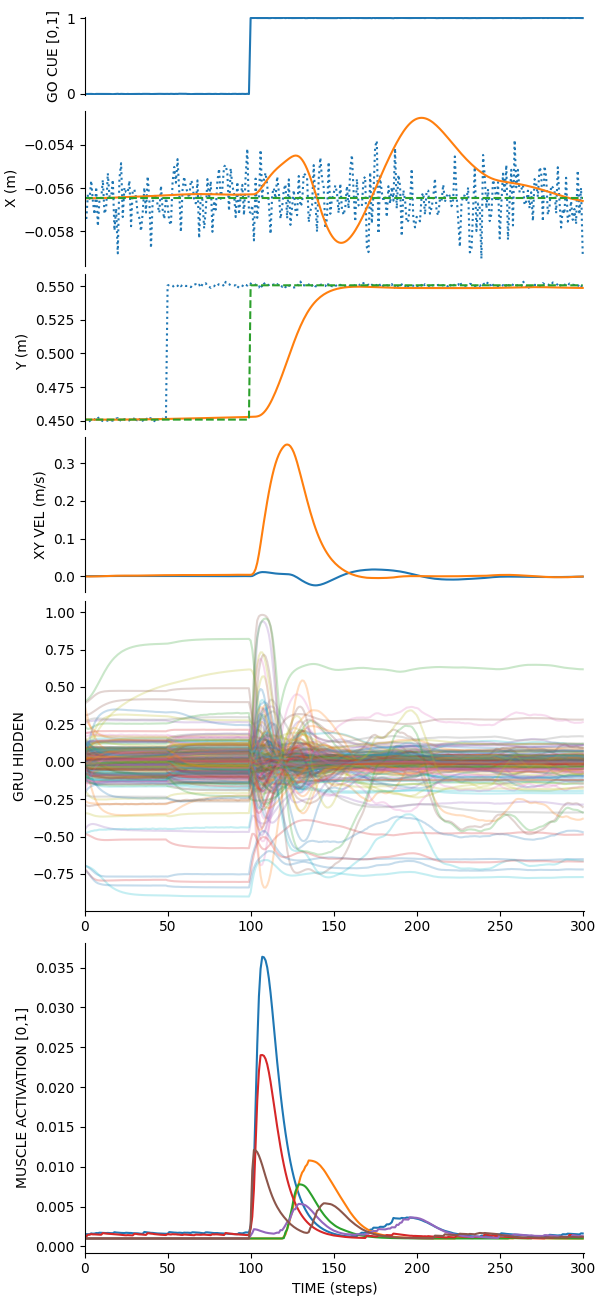

(<Figure size 600x1300 with 6 Axes>,
 [<Axes: ylabel='GO CUE [0,1]'>,
  <Axes: ylabel='X (m)'>,
  <Axes: ylabel='Y (m)'>,
  <Axes: ylabel='XY VEL (m/s)'>,
  <Axes: ylabel='GRU HIDDEN'>,
  <Axes: xlabel='TIME (steps)', ylabel='MUSCLE ACTIVATION [0,1]'>])

In [3]:
# Plot results
plot_handpaths(episode_data=episode_data)
plot_signals(episode_data=episode_data, trial=2)

In [4]:
h = episode_data['hidden'].detach().numpy()
print(f"hidden activity shape: {np.shape(h)}")

hidden activity shape: (8, 301, 256)


In [5]:
# Mean across conditions (axis=0 is now batch/conditions)
n_mean = np.mean(h, axis=0, keepdims=True)

# Range across conditions
n_range = np.max(h, axis=0, keepdims=True) - np.min(h, axis=0, keepdims=True)

# Scale
h = (h - n_mean) / (n_range + 5)

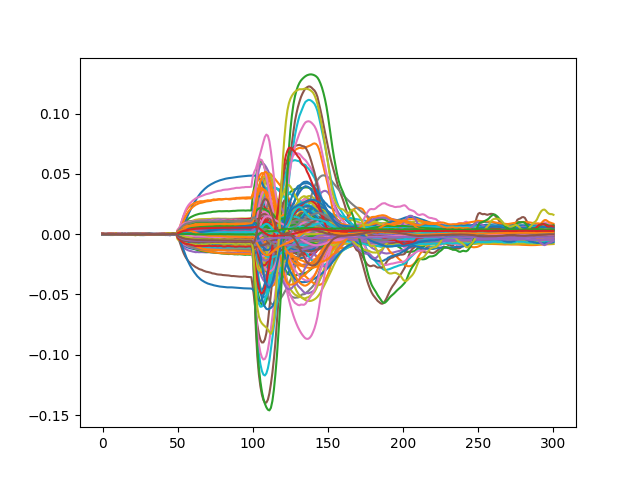

In [6]:
plt.figure()
plt.plot(h[0,:,:])
plt.show()

In [7]:
from sklearn.decomposition import PCA

# h shape is (batch, time, neurons) = (8, 301, 256)
# Transpose to X shape: (time, condition, neurons)
X = np.transpose(h, (1, 0, 2))   # (301, 8, 256)

# Reshape for PCA: (samples, features)
X_flat = X.reshape(-1, X.shape[-1])   # -> (2408, 256)

# Run PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_flat)     # (2408, 3)

# Reshape back to (time, condition, PCs)
X_pca = X_pca.reshape(X.shape[0], X.shape[1], 3)  # -> (301, 8, 3)

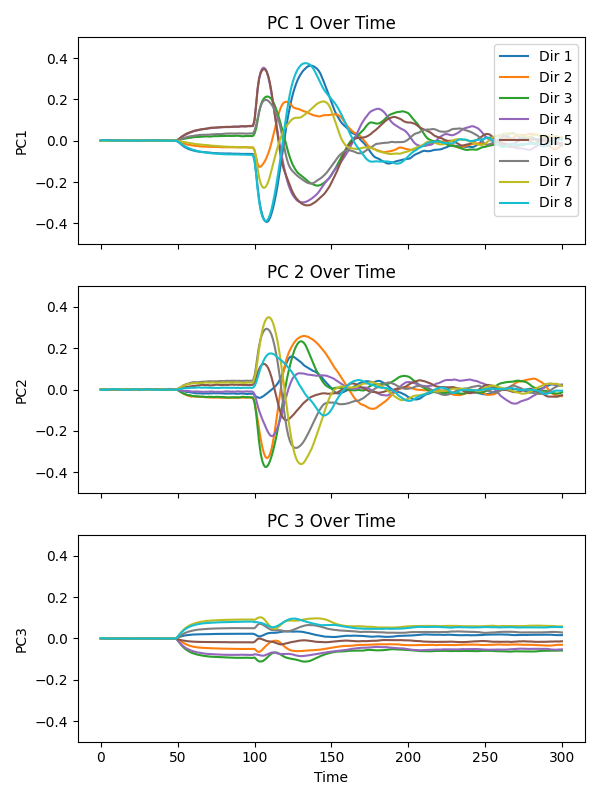

In [8]:
time = np.arange(X_pca.shape[0])
colors = plt.cm.tab10(np.linspace(0, 1, X_pca.shape[1]))

fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

for i, ax in enumerate(axes):
    for cond in range(X_pca.shape[1]):
        ax.plot(time, X_pca[:, cond, i], color=colors[cond], label=f"Dir {cond+1}" if i==0 else None)
        ax.set_ylim(-0.5, 0.5)
    
    ax.set_ylabel(f"PC{i+1}")
    ax.set_title(f"PC {i+1} Over Time")

axes[-1].set_xlabel("Time")
axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

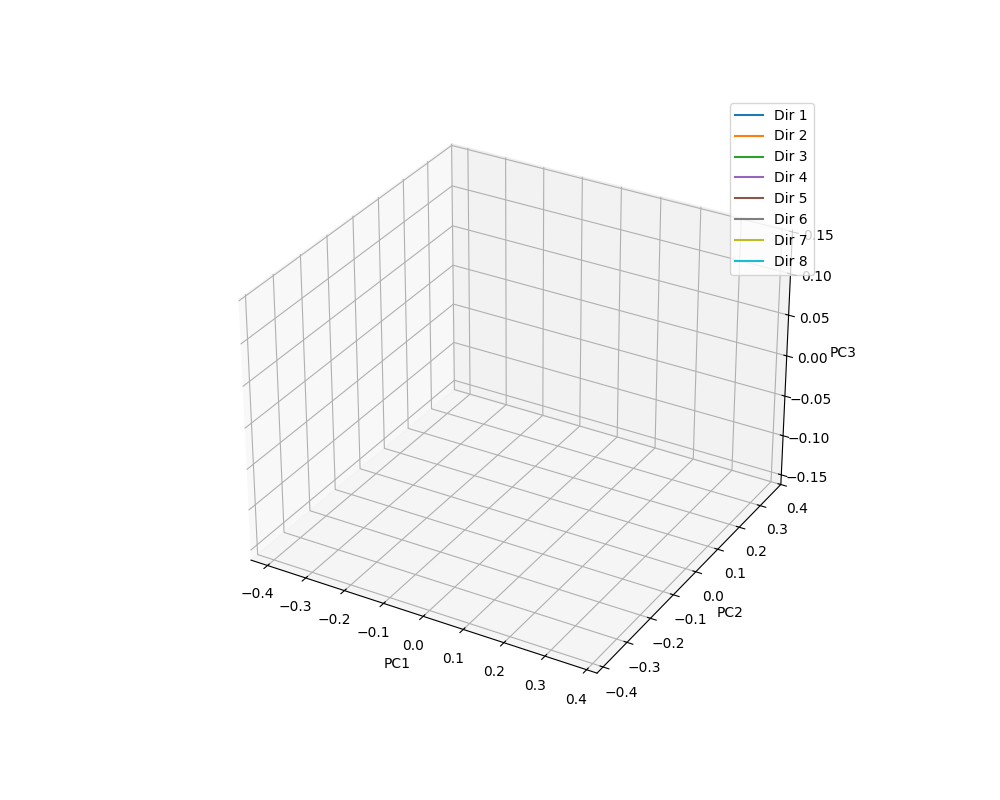

In [9]:
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.tab10(np.linspace(0, 1, X.shape[1]))
go_times = episode_data['delay_go_times']

# Set axis limits based on full data range
ax.set_xlim(X_pca[:, :, 0].min() - 0.05, X_pca[:, :, 0].max() + 0.05)
ax.set_ylim(X_pca[:, :, 1].min() - 0.05, X_pca[:, :, 1].max() + 0.05)
ax.set_zlim(X_pca[:, :, 2].min() - 0.05, X_pca[:, :, 2].max() + 0.05)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Initialize line objects for each condition
lines = [ax.plot([], [], [], color=colors[cond], label=f"Dir {cond+1}")[0] 
         for cond in range(X.shape[1])]

# Initialize markers for current position (circles) and go signal (squares)
markers = [ax.scatter([], [], [], color=colors[cond], s=60, zorder=5) 
           for cond in range(X.shape[1])]
go_markers = [ax.scatter([], [], [], color=colors[cond], marker='s', s=80, 
                         edgecolors='black', linewidths=1, zorder=6) 
              for cond in range(X.shape[1])]

# Time text
time_text = ax.text2D(0.02, 0.95, '', transform=ax.transAxes, fontsize=12)

ax.legend(loc='upper right')

def init():
    for line in lines:
        line.set_data([], [])
        line.set_3d_properties([])
    for marker in markers:
        marker._offsets3d = ([], [], [])
    for go_marker in go_markers:
        go_marker._offsets3d = ([], [], [])
    time_text.set_text('')
    return lines + markers + go_markers + [time_text]

def animate(frame):
    for cond in range(X.shape[1]):
        # Update trajectory line
        lines[cond].set_data(X_pca[:frame+1, cond, 0], X_pca[:frame+1, cond, 1])
        lines[cond].set_3d_properties(X_pca[:frame+1, cond, 2])
        
        # Update current position marker
        markers[cond]._offsets3d = ([X_pca[frame, cond, 0]], 
                                    [X_pca[frame, cond, 1]], 
                                    [X_pca[frame, cond, 2]])
        
        # Show go signal marker once we pass that time
        if frame >= go_times[cond]:
            go_markers[cond]._offsets3d = ([X_pca[go_times[cond], cond, 0]],
                                           [X_pca[go_times[cond], cond, 1]],
                                           [X_pca[go_times[cond], cond, 2]])
    
    time_text.set_text(f't = {frame * episode_data["dt"]:.2f}s')
    return lines + markers + go_markers + [time_text]

# Animate every 3rd frame for speed (adjust interval for playback speed)
anim = FuncAnimation(fig, animate, init_func=init, frames=range(0, X_pca.shape[0], 3),
                     interval=30, blit=False)

plt.show()